
===== Parratt double-layer XRR fit =====
Model: Air / Layer 1 / Layer 2 / Substrate
Layer 1 thickness = 21.25 Å = 2.12 nm
Layer 2 thickness = 156.39 Å = 15.64 nm
Total thickness = 177.64 Å = 17.76 nm

Fixed parameters:
Layer 1 electron density = 1.200 e/Å³
Layer 2 electron density = 1.470 e/Å³
Substrate electron density = 1.170 e/Å³
Air/Layer1 roughness = 2.42 Å
Layer1/Layer2 roughness = 4.18 Å
Layer2/Substrate roughness = 4.36 Å

Fitted correction parameters:
Scale factor = 2.207e-01
Background = 4.410e-08
Cost = 7.6381e+00


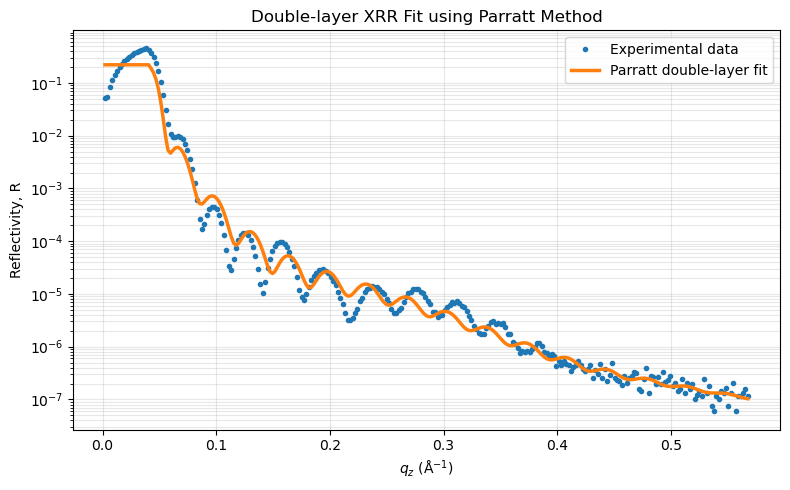

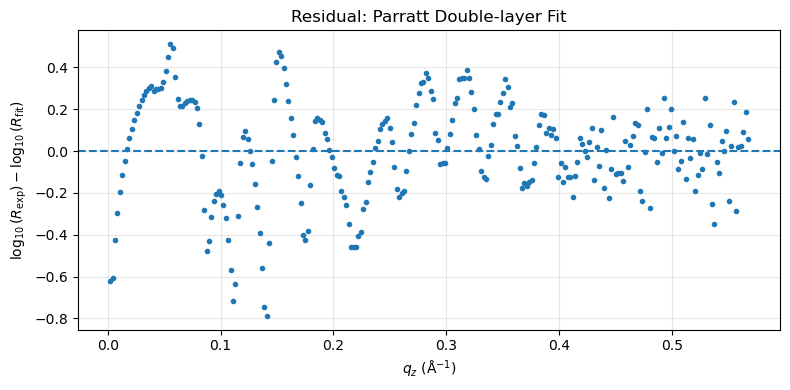

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

# ============================================================
# 1. User settings
# ============================================================

file_path = r"D:\course\MSE461\lab1\XRR_R_q_dR.csv"

fit_all_q = True
q_min_fit = 0.10
q_max_fit = 0.38

rho_air = 0.0
rho_layer1 = 1.20
rho_layer2 = 1.47
rho_sub = 1.17

d1_init = 30.0
d2_init = 150.0

sigma01 = 2.42
sigma12 = 4.18
sigma23 = 4.36

scale_init = 1.0
background_init = 1e-7

r_e = 2.8179403262e-5

# ============================================================
# 2. Load converted CSV data
# ============================================================

df = pd.read_csv(file_path)

df = df.rename(columns={
    "q_A^-1": "q",
    "R": "R",
    "dR": "dR"
})

df = df[["q", "R", "dR"]].copy()

for c in ["q", "R", "dR"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna()
df = df[(df["q"] > 0) & (df["R"] > 0)]
df = df.sort_values("q")

q = df["q"].to_numpy(float)
R = df["R"].to_numpy(float)
dR = df["dR"].to_numpy(float)

if fit_all_q:
    fit_mask = np.ones_like(q, dtype=bool)
else:
    fit_mask = (q >= q_min_fit) & (q <= q_max_fit)

q_fit = q[fit_mask]
R_fit = R[fit_mask]
logR_fit = np.log10(R_fit)

# ============================================================
# 3. Parratt reflectivity
# ============================================================

def parratt_double_layer(
    q,
    d1,
    d2,
    rho1,
    rho2,
    rho_sub,
    sigma01,
    sigma12,
    sigma23,
    scale,
    background
):
    q = np.asarray(q, dtype=float)

    rho = np.array([
        rho_air,
        rho1,
        rho2,
        rho_sub
    ], dtype=float)

    qc2 = 16.0 * np.pi * r_e * rho

    kz = np.sqrt(q[:, None]**2 - qc2[None, :] + 0j) / 2.0

    r_total = np.zeros_like(q, dtype=complex)

    sigmas = [sigma01, sigma12, sigma23]
    thickness_below = [d1, d2, 0.0]

    for j in [2, 1, 0]:
        k_j = kz[:, j]
        k_next = kz[:, j + 1]

        r_j = (k_j - k_next) / (k_j + k_next)

        r_j *= np.exp(-2.0 * k_j * k_next * sigmas[j]**2)

        phase = np.exp(2j * k_next * thickness_below[j])

        r_total = (r_j + r_total * phase) / (
            1.0 + r_j * r_total * phase
        )

    R_model = np.abs(r_total)**2

    return scale * R_model + background

# ============================================================
# 4. Residual
# ============================================================

def residual(params):
    d1, d2, log_scale, log_bg = params

    scale = 10**log_scale
    background = 10**log_bg

    R_model = parratt_double_layer(
        q_fit,
        d1=d1,
        d2=d2,
        rho1=rho_layer1,
        rho2=rho_layer2,
        rho_sub=rho_sub,
        sigma01=sigma01,
        sigma12=sigma12,
        sigma23=sigma23,
        scale=scale,
        background=background
    )

    return np.log10(R_model) - logR_fit

# ============================================================
# 5. Fitting
# ============================================================

p0 = np.array([
    d1_init,
    d2_init,
    np.log10(scale_init),
    np.log10(background_init)
], dtype=float)

lower = np.array([
    5.0,
    100.0,
    np.log10(0.01),
    -10.0
], dtype=float)

upper = np.array([
    60.0,
    200.0,
    np.log10(5.0),
    -5.0
], dtype=float)

result = least_squares(
    residual,
    p0,
    bounds=(lower, upper),
    max_nfev=10000
)

if not result.success:
    print("Warning: fit did not fully converge.")
    print(result.message)

# ============================================================
# 6. Extract results
# ============================================================

d1_fit, d2_fit, log_scale_fit, log_bg_fit = result.x

scale_fit = 10**log_scale_fit
background_fit = 10**log_bg_fit

R_best = parratt_double_layer(
    q,
    d1=d1_fit,
    d2=d2_fit,
    rho1=rho_layer1,
    rho2=rho_layer2,
    rho_sub=rho_sub,
    sigma01=sigma01,
    sigma12=sigma12,
    sigma23=sigma23,
    scale=scale_fit,
    background=background_fit
)

R_fit_best = parratt_double_layer(
    q_fit,
    d1=d1_fit,
    d2=d2_fit,
    rho1=rho_layer1,
    rho2=rho_layer2,
    rho_sub=rho_sub,
    sigma01=sigma01,
    sigma12=sigma12,
    sigma23=sigma23,
    scale=scale_fit,
    background=background_fit
)

# ============================================================
# 7. Print results
# ============================================================

print("\n===== Parratt double-layer XRR fit =====")
print("Model: Air / Layer 1 / Layer 2 / Substrate")
print(f"Layer 1 thickness = {d1_fit:.2f} Å = {d1_fit/10:.2f} nm")
print(f"Layer 2 thickness = {d2_fit:.2f} Å = {d2_fit/10:.2f} nm")
print(f"Total thickness = {d1_fit + d2_fit:.2f} Å = {(d1_fit + d2_fit)/10:.2f} nm")
print()
print("Fixed parameters:")
print(f"Layer 1 electron density = {rho_layer1:.3f} e/Å³")
print(f"Layer 2 electron density = {rho_layer2:.3f} e/Å³")
print(f"Substrate electron density = {rho_sub:.3f} e/Å³")
print(f"Air/Layer1 roughness = {sigma01:.2f} Å")
print(f"Layer1/Layer2 roughness = {sigma12:.2f} Å")
print(f"Layer2/Substrate roughness = {sigma23:.2f} Å")
print()
print("Fitted correction parameters:")
print(f"Scale factor = {scale_fit:.3e}")
print(f"Background = {background_fit:.3e}")
print(f"Cost = {result.cost:.4e}")

# ============================================================
# 8. Plot fit, no error bar
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    q,
    R,
    ".",
    markersize=6,
    color="tab:blue",
    label="Experimental data"
)

plt.plot(
    q,
    R_best,
    "-",
    linewidth=2.5,
    color="tab:orange",
    label="Parratt double-layer fit"
)

plt.yscale("log")
plt.xlabel(r"$q_z$ ($\mathrm{\AA^{-1}}$)")
plt.ylabel("Reflectivity, R")
plt.title("Double-layer XRR Fit using Parratt Method")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# 9. Residual plot
# ============================================================

plt.figure(figsize=(8, 4))

plt.plot(
    q_fit,
    np.log10(R_fit) - np.log10(R_fit_best),
    "."
)

plt.axhline(0, linestyle="--")
plt.xlabel(r"$q_z$ ($\mathrm{\AA^{-1}}$)")
plt.ylabel(r"$\log_{10}(R_\mathrm{exp}) - \log_{10}(R_\mathrm{fit})$")
plt.title("Residual: Parratt Double-layer Fit")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

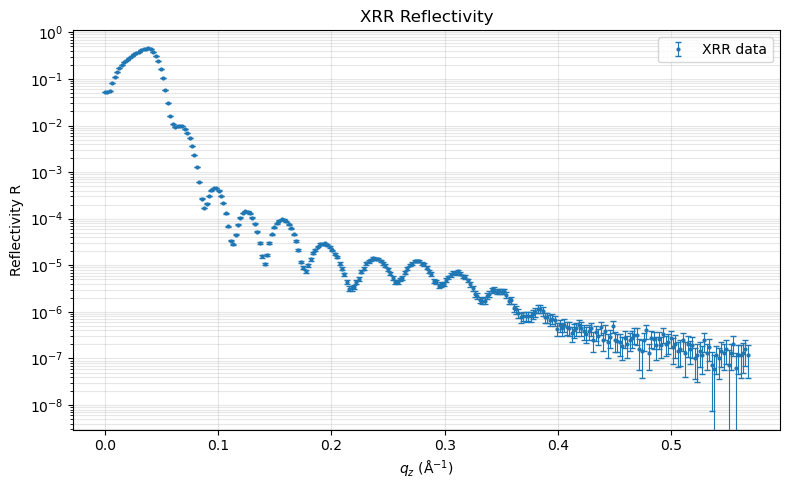

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Load data
# ============================================================

file_path = r"D:\course\MSE461\lab1\XRR_R_q_dR.csv"

df = pd.read_csv(file_path)

df = df.rename(columns={
    "q_A^-1": "q",
    "R": "R",
    "dR": "dR"
})

q = df["q"].to_numpy()
R = df["R"].to_numpy()
dR = df["dR"].to_numpy()

# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(8,5))

plt.errorbar(
    q,
    R,
    yerr=dR,
    fmt='.',
    markersize=4,
    capsize=2,
    elinewidth=0.8,
    label='XRR data'
)

plt.yscale('log')

plt.xlabel(r'$q_z$ ($\mathrm{\AA^{-1}}$)')
plt.ylabel('Reflectivity R')
plt.title('XRR Reflectivity')

plt.grid(True, which='both', alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

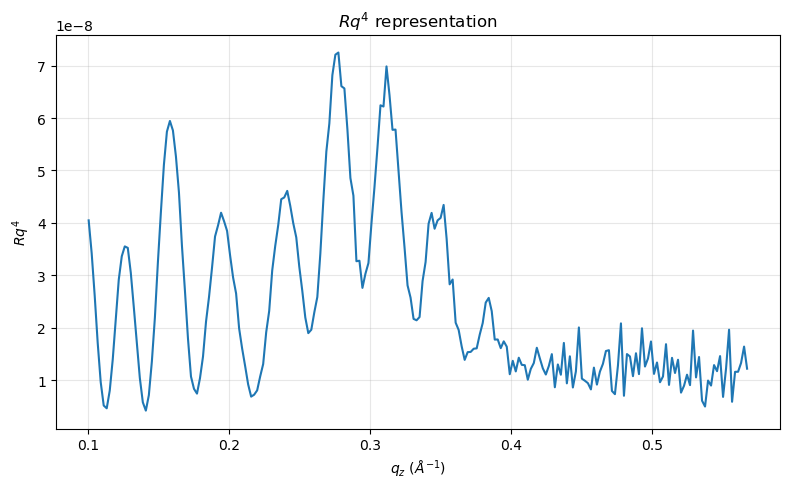

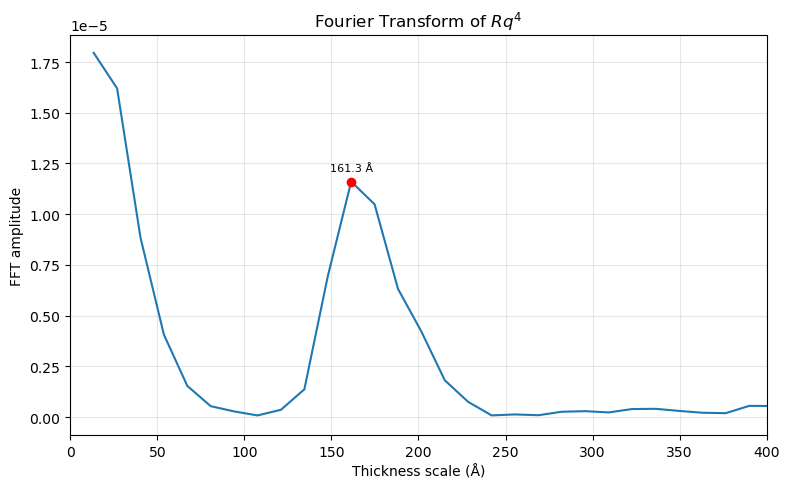


===== Fourier Peaks =====
Peak  1:   161.34 Å    16.13 nm


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# ============================================================
# 1. Load data
# ============================================================

file_path = r"D:\course\MSE461\lab1\XRR_R_q_dR.csv"

df = pd.read_csv(file_path)

df = df.rename(columns={
    "q_A^-1": "q",
    "R": "R",
    "dR": "dR"
})

df = df.dropna()
df = df[(df["q"] > 0) & (df["R"] > 0)]
df = df.sort_values("q")

q = df["q"].to_numpy()
R = df["R"].to_numpy()

# ============================================================
# 2. q > 0.1
# ============================================================

mask = q > 0.1

q_cut = q[mask]
R_cut = R[mask]

Rq4 = R_cut * q_cut**4

# ============================================================
# 3. Plot Rq^4
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(
    q_cut,
    Rq4,
    '-',
    linewidth=1.5
)

plt.xlabel(r"$q_z$ ($\AA^{-1}$)")
plt.ylabel(r"$Rq^4$")
plt.title(r"$Rq^4$ representation")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# 4. Uniform interpolation
# ============================================================

N = 4096

q_uniform = np.linspace(
    q_cut.min(),
    q_cut.max(),
    N
)

Rq4_uniform = np.interp(
    q_uniform,
    q_cut,
    Rq4
)

# ============================================================
# 5. Window + FFT
# ============================================================

signal = Rq4_uniform - np.mean(Rq4_uniform)

window = np.hanning(N)

signal *= window

dq = q_uniform[1] - q_uniform[0]

FT = np.fft.rfft(signal)

freq = np.fft.rfftfreq(
    N,
    d=dq
)

z = 2*np.pi*freq

FT_amp = np.abs(FT)

# remove zero frequency
z = z[1:]
FT_amp = FT_amp[1:]

# ============================================================
# 6. Peak finding
# ============================================================

peak_indices, peak_properties = find_peaks(
    FT_amp,
    prominence=np.max(FT_amp)*0.05
)

peak_heights = FT_amp[peak_indices]

# sort by peak height
order = np.argsort(peak_heights)[::-1]

peak_indices = peak_indices[order]

# take strongest 10 peaks
peak_indices = peak_indices[:10]

# ============================================================
# 7. Plot FFT + peaks
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(
    z,
    FT_amp,
    '-'
)

plt.plot(
    z[peak_indices],
    FT_amp[peak_indices],
    'ro'
)

for idx in peak_indices:

    plt.annotate(
        f"{z[idx]:.1f} Å",
        (z[idx], FT_amp[idx]),
        xytext=(0,8),
        textcoords='offset points',
        ha='center',
        fontsize=8
    )

plt.xlabel("Thickness scale (Å)")
plt.ylabel("FFT amplitude")
plt.title("Fourier Transform of $Rq^4$")

plt.xlim(0,400)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# 8. Print peak table
# ============================================================

print("\n===== Fourier Peaks =====")

for i, idx in enumerate(peak_indices):

    print(
        f"Peak {i+1:2d}: "
        f"{z[idx]:8.2f} Å   "
        f"{z[idx]/10:6.2f} nm"
    )

Number of initial guesses = 3416
Stage 1 finished 100/3416, best cost = 8.8885e+00
Stage 1 finished 200/3416, best cost = 8.8885e+00
Stage 1 finished 300/3416, best cost = 8.8885e+00
Stage 1 finished 400/3416, best cost = 8.8885e+00
Stage 1 finished 500/3416, best cost = 8.8885e+00
Stage 1 finished 600/3416, best cost = 8.8885e+00
Stage 1 finished 700/3416, best cost = 8.8885e+00
Stage 1 finished 800/3416, best cost = 8.8885e+00
Stage 1 finished 900/3416, best cost = 8.8885e+00
Stage 1 finished 1000/3416, best cost = 8.8885e+00
Stage 1 finished 1100/3416, best cost = 8.8885e+00
Stage 1 finished 1200/3416, best cost = 8.8885e+00
Stage 1 finished 1300/3416, best cost = 8.8885e+00
Stage 1 finished 1400/3416, best cost = 8.8885e+00
Stage 1 finished 1500/3416, best cost = 8.8885e+00
Stage 1 finished 1600/3416, best cost = 8.8885e+00
Stage 1 finished 1700/3416, best cost = 8.8885e+00
Stage 1 finished 1800/3416, best cost = 8.8885e+00
Stage 1 finished 1900/3416, best cost = 8.8885e+00
Stage 1

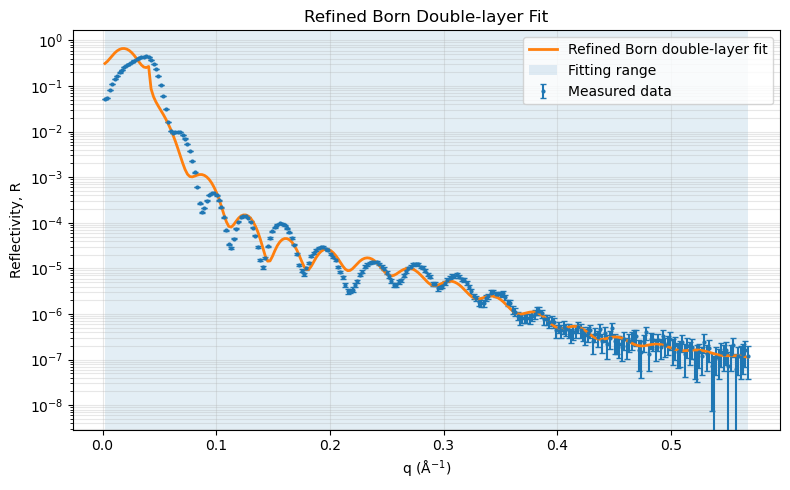

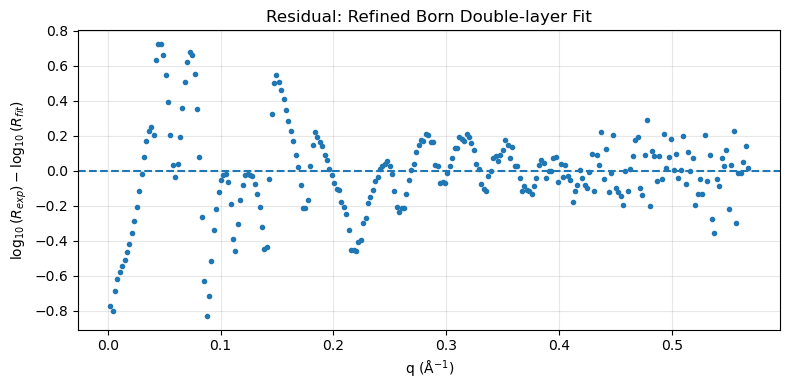

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from numba import njit
from scipy.optimize import least_squares

# ============================================================
# 1. User settings
# ============================================================

file_path = r"D:\course\MSE461\lab1\XRR_R_q_dR.csv"

# Fit all q
fit_all_q = True

# Electron densities, e/Å^3
rho_air = 0.0
rho_TiN_main = 1.47
rho_sub = 1.17

# Thickness target, Å
total_t_target = 170.0

# Classical electron radius, Å
r_e = 2.8179403262e-5

# ============================================================
# 2. Load converted CSV data
# ============================================================

df = pd.read_csv(file_path)

df = df.rename(columns={
    "q_A^-1": "q",
    "R": "R",
    "dR": "dR"
})

df = df[["q", "R", "dR"]].copy()

for c in ["q", "R", "dR"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna()
df = df[(df["q"] > 0) & (df["R"] > 0)]
df = df.sort_values("q")

q = df["q"].to_numpy(dtype=np.float64)
R = df["R"].to_numpy(dtype=np.float64)
dR = df["dR"].to_numpy(dtype=np.float64)

# Use all q
q_min_fit = q.min()
q_max_fit = q.max()

q_fit = q.copy()
R_fit = R.copy()
dR_fit = dR.copy()

logR_fit = np.log10(R_fit)

# ============================================================
# 3. Fresnel reflectivity
# ============================================================

def fresnel_reflectivity(q, rho_sub):
    q = np.asarray(q, dtype=np.float64)

    qc2 = 16.0 * np.pi * r_e * rho_sub

    kz0 = q / 2.0
    kz1 = np.sqrt(q**2 - qc2 + 0j) / 2.0

    r = (kz0 - kz1) / (kz0 + kz1)

    return np.abs(r)**2


RF_all = fresnel_reflectivity(q, rho_sub).astype(np.float64)
RF_fit = fresnel_reflectivity(q_fit, rho_sub).astype(np.float64)

# ============================================================
# 4. Born double-layer model
# ============================================================

@njit(cache=True)
def born_double_layer_numba(
    q,
    RF,
    d1,
    d2,
    rho1,
    sigma01,
    sigma12,
    sigma23,
    scale,
    background,
    rho_TiN_main,
    rho_sub
):
    n = q.size

    R_model = np.empty(n, dtype=np.float64)

    rho0 = 0.0
    rho2 = rho_TiN_main
    rho3 = rho_sub

    z01 = 0.0
    z12 = d1
    z23 = d1 + d2

    drho01 = rho1 - rho0
    drho12 = rho2 - rho1
    drho23 = rho3 - rho2

    norm = rho_sub - rho0

    for i in range(n):
        qi = q[i]

        A_real = 0.0
        A_imag = 0.0

        # interface 0/1
        damping01 = np.exp(-0.5 * qi * qi * sigma01 * sigma01)
        phase01 = qi * z01
        A_real += drho01 * damping01 * np.cos(phase01)
        A_imag += drho01 * damping01 * np.sin(phase01)

        # interface 1/2
        damping12 = np.exp(-0.5 * qi * qi * sigma12 * sigma12)
        phase12 = qi * z12
        A_real += drho12 * damping12 * np.cos(phase12)
        A_imag += drho12 * damping12 * np.sin(phase12)

        # interface 2/3
        damping23 = np.exp(-0.5 * qi * qi * sigma23 * sigma23)
        phase23 = qi * z23
        A_real += drho23 * damping23 * np.cos(phase23)
        A_imag += drho23 * damping23 * np.sin(phase23)

        A2 = A_real * A_real + A_imag * A_imag

        R_model[i] = scale * RF[i] * A2 / (norm * norm) + background

    return R_model

# ============================================================
# 5. Bounds
# ============================================================

lower2 = np.array([
    2.0,              # d1, Å
    100.0,            # d2, Å
    0.60,             # rho1
    0.2,              # sigma01
    0.2,              # sigma12
    0.2,              # sigma23
    np.log10(0.3),    # scale
    -10.0             # background
], dtype=np.float64)

upper2 = np.array([
    60.0,             # d1, Å
    190.0,            # d2, Å
    1.45,             # rho1
    15.0,             # sigma01
    15.0,             # sigma12
    15.0,             # sigma23
    np.log10(8.0),    # scale
    -5.5              # background
], dtype=np.float64)

# ============================================================
# 6. Residual
# ============================================================

@njit(cache=True)
def residual_numba_v2(
    params,
    q_fit,
    RF_fit,
    logR_fit,
    rho_TiN_main,
    rho_sub,
    total_t_target
):
    d1 = params[0]
    d2 = params[1]
    rho1 = params[2]
    sigma01 = params[3]
    sigma12 = params[4]
    sigma23 = params[5]
    log_scale = params[6]
    log_bg = params[7]

    scale = 10.0 ** log_scale
    background = 10.0 ** log_bg

    R_model = born_double_layer_numba(
        q_fit,
        RF_fit,
        d1,
        d2,
        rho1,
        sigma01,
        sigma12,
        sigma23,
        scale,
        background,
        rho_TiN_main,
        rho_sub
    )

    n = q_fit.size

    res = np.empty(n + 3, dtype=np.float64)

    for i in range(n):
        res[i] = np.log10(R_model[i]) - logR_fit[i]

    # weaker total-thickness penalty
    res[n] = ((d1 + d2) - total_t_target) / 12.0

    # keep rho1 below main TiN
    density_order = rho1 - rho_TiN_main

    if density_order < 0.0:
        density_order = 0.0

    res[n + 1] = density_order / 0.05

    # much weaker scale penalty
    res[n + 2] = (log_scale - 0.0) / 0.75

    return res


def residual_fast_v2(params):
    return residual_numba_v2(
        params.astype(np.float64),
        q_fit,
        RF_fit,
        logR_fit,
        rho_TiN_main,
        rho_sub,
        total_t_target
    )

# ============================================================
# 7. Generate fewer starting points
# ============================================================

rng = np.random.default_rng(1)

initial_guesses2 = []

# Physics-informed manual guesses
for d1 in [3, 8, 15, 30]:
    for total_d in [160, 170, 180]:
        d2 = total_d - d1

        if d2 < lower2[1] or d2 > upper2[1]:
            continue

        for rho1 in [0.9, 1.2, 1.4]:
            for sigma01 in [0.5, 2, 6]:
                for sigma12 in [0.5, 2, 6]:
                    for sigma23 in [1, 4, 8]:
                        for scale0 in [1, 3, 6]:
                            initial_guesses2.append([
                                d1,
                                d2,
                                rho1,
                                sigma01,
                                sigma12,
                                sigma23,
                                np.log10(scale0),
                                -7.0
                            ])

# Random starts
for _ in range(500):
    d1 = rng.uniform(2, 60)

    total_d = rng.normal(170, 12)
    total_d = np.clip(total_d, 150, 190)

    d2 = total_d - d1

    if d2 < lower2[1] or d2 > upper2[1]:
        d2 = rng.uniform(lower2[1], upper2[1])

    initial_guesses2.append([
        d1,
        d2,
        rng.uniform(0.6, 1.45),
        rng.uniform(0.2, 10),
        rng.uniform(0.2, 10),
        rng.uniform(0.2, 12),
        rng.uniform(np.log10(0.5), np.log10(8.0)),
        rng.uniform(-9.5, -5.8)
    ])

initial_guesses2 = np.array(initial_guesses2, dtype=np.float64)

print("Number of initial guesses =", len(initial_guesses2))

_ = residual_fast_v2(initial_guesses2[0])

# ============================================================
# 8. Stage 1: broad search
# ============================================================

best_result = None
best_cost = np.inf

for i, p0 in enumerate(initial_guesses2):

    result = least_squares(
        residual_fast_v2,
        p0,
        bounds=(lower2, upper2),
        max_nfev=400,
        xtol=1e-6,
        ftol=1e-6,
        gtol=1e-6
    )

    if result.cost < best_cost:
        best_cost = result.cost
        best_result = result

    if (i + 1) % 100 == 0:
        print(f"Stage 1 finished {i+1}/{len(initial_guesses2)}, best cost = {best_cost:.4e}")

# ============================================================
# 8b. Stage 2: local refinement around best result
# ============================================================

p_best = best_result.x.copy()

local_guesses = [p_best]

for _ in range(150):
    p = p_best.copy()

    p[0] += rng.normal(0, 5)      # d1
    p[1] += rng.normal(0, 5)      # d2
    p[2] += rng.normal(0, 0.08)   # rho1
    p[3] += rng.normal(0, 1.5)    # sigma01
    p[4] += rng.normal(0, 1.5)    # sigma12
    p[5] += rng.normal(0, 2.0)    # sigma23
    p[6] += rng.normal(0, 0.15)   # log scale
    p[7] += rng.normal(0, 0.4)    # log background

    p = np.clip(p, lower2, upper2)
    local_guesses.append(p)

local_guesses = np.array(local_guesses, dtype=np.float64)

for i, p0 in enumerate(local_guesses):

    result = least_squares(
        residual_fast_v2,
        p0,
        bounds=(lower2, upper2),
        max_nfev=1500,
        xtol=1e-8,
        ftol=1e-8,
        gtol=1e-8
    )

    if result.cost < best_cost:
        best_cost = result.cost
        best_result = result

    if (i + 1) % 50 == 0:
        print(f"Stage 2 finished {i+1}/{len(local_guesses)}, best cost = {best_cost:.4e}")
# ============================================================
# 9. Extract and plot
# ============================================================

d1_fit, d2_fit, rho1_fit, sigma01_fit, sigma12_fit, sigma23_fit, log_scale_fit, log_bg_fit = best_result.x

scale_fit = 10**log_scale_fit
background_fit = 10**log_bg_fit
rho2_fit = rho_TiN_main

R_best = born_double_layer_numba(
    q.astype(np.float64),
    RF_all,
    d1_fit,
    d2_fit,
    rho1_fit,
    sigma01_fit,
    sigma12_fit,
    sigma23_fit,
    scale_fit,
    background_fit,
    rho_TiN_main,
    rho_sub
)

R_fit_best = born_double_layer_numba(
    q_fit,
    RF_fit,
    d1_fit,
    d2_fit,
    rho1_fit,
    sigma01_fit,
    sigma12_fit,
    sigma23_fit,
    scale_fit,
    background_fit,
    rho_TiN_main,
    rho_sub
)

print("\n===== Refined Born double-layer fit =====")
print(f"Layer 1 thickness = {d1_fit:.2f} Å = {d1_fit/10:.2f} nm")
print(f"Layer 2 thickness = {d2_fit:.2f} Å = {d2_fit/10:.2f} nm")
print(f"Total thickness = {d1_fit+d2_fit:.2f} Å = {(d1_fit+d2_fit)/10:.2f} nm")
print(f"Layer 1 electron density = {rho1_fit:.3f} e/Å³")
print(f"Layer 2 electron density fixed = {rho2_fit:.3f} e/Å³")
print(f"Al2O3 electron density fixed = {rho_sub:.3f} e/Å³")
print(f"Air/Layer1 roughness = {sigma01_fit:.2f} Å")
print(f"Layer1/Layer2 roughness = {sigma12_fit:.2f} Å")
print(f"Layer2/Al2O3 roughness = {sigma23_fit:.2f} Å")
print(f"Scale factor = {scale_fit:.3f}")
print(f"Background = {background_fit:.3e}")
print(f"Cost = {best_result.cost:.4e}")

# ============================================================
# 10. Plot fit
# ============================================================

plt.figure(figsize=(8, 5))

plt.errorbar(
    q,
    R,
    yerr=dR,
    fmt=".",
    markersize=4,
    capsize=2,
    label="Measured data"
)

plt.plot(
    q,
    R_best,
    "-",
    linewidth=2,
    label="Refined Born double-layer fit"
)

plt.axvspan(
    q_min_fit,
    q_max_fit,
    alpha=0.12,
    label="Fitting range"
)

plt.yscale("log")
plt.xlabel(r"q ($\mathrm{\AA^{-1}}$)")
plt.ylabel("Reflectivity, R")
plt.title("Refined Born Double-layer Fit")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# 11. Residual plot
# ============================================================

plt.figure(figsize=(8, 4))

plt.plot(
    q_fit,
    np.log10(R_fit) - np.log10(R_fit_best),
    "."
)

plt.axhline(0, linestyle="--")
plt.xlabel(r"q ($\mathrm{\AA^{-1}}$)")
plt.ylabel(r"$\log_{10}(R_{exp}) - \log_{10}(R_{fit})$")
plt.title("Residual: Refined Born Double-layer Fit")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

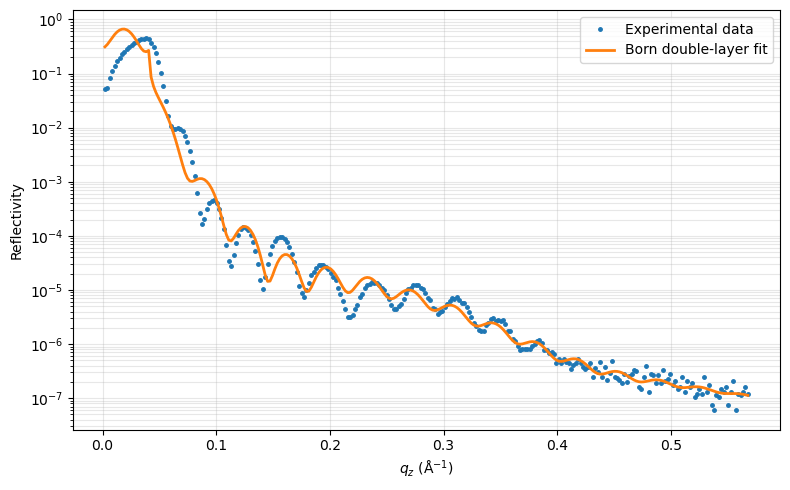

In [8]:
# ============================================================
# Clean plot for report
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(
    q,
    R,
    ".",
    markersize=5,
    color="tab:blue",
    label="Experimental data"
)

plt.plot(
    q,
    R_best,
    "-",
    linewidth=2,
    color="tab:orange",
    label="Born double-layer fit"
)

plt.yscale("log")

plt.xlabel(r"$q_z$ ($\mathrm{\AA^{-1}}$)")
plt.ylabel("Reflectivity")

plt.legend()

plt.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

# Testing


===== Parratt double-layer XRR fit =====
Model: Air / Layer 1 / Layer 2 / Substrate
Layer 1 thickness = 21.32 Å = 2.13 nm
Layer 2 thickness = 162.54 Å = 16.25 nm
Total thickness = 183.86 Å = 18.39 nm

Fitted parameters:
Layer 1 electron density = 1.076 e/Å³
Air/Layer1 roughness = 2.12 Å
Layer1/Layer2 roughness = 3.86 Å
Layer2/Substrate roughness = 7.61 Å
Scale factor = 2.564e-01
Background = 4.505e-09

Fixed parameters:
Layer 2 electron density = 1.470 e/Å³
Substrate electron density = 1.170 e/Å³

Cost = 6.4006e+00


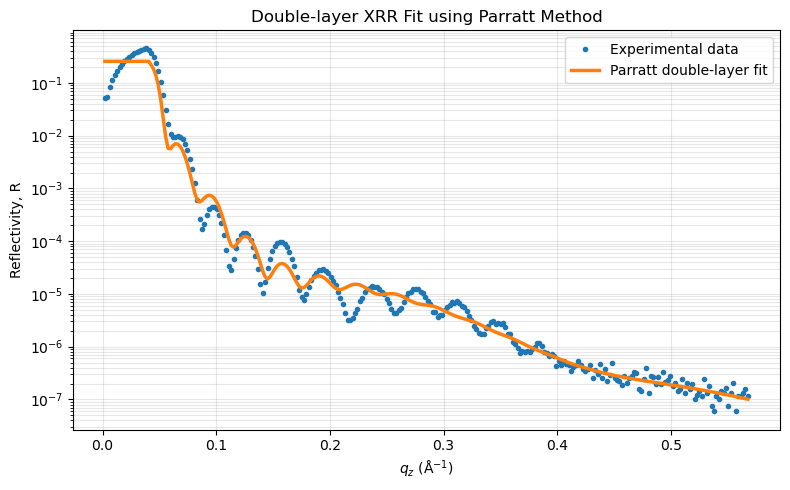

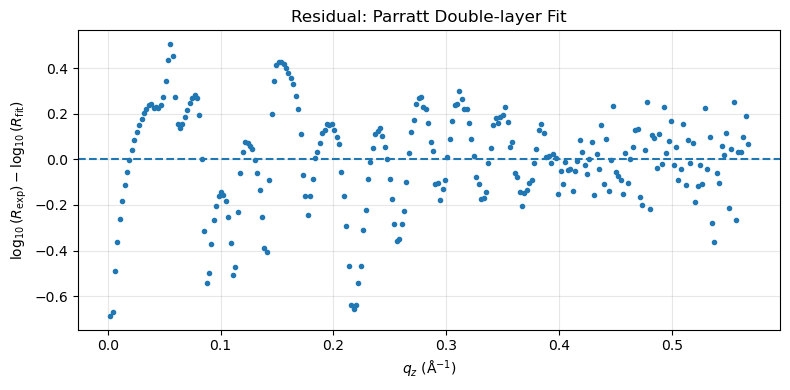

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

# ============================================================
# 1. User settings
# ============================================================

file_path = r"D:\course\MSE461\lab1\XRR_R_q_dR.csv"

fit_all_q = True
q_min_fit = 0.10
q_max_fit = 0.38

rho_air = 0.0
rho_layer1_init = 1.20
rho_layer2 = 1.47
rho_sub = 1.17

d1_init = 30.0
d2_init = 150.0

# Initial roughnesses from Born fit, Å
sigma01_init = 2.42
sigma12_init = 4.18
sigma23_init = 4.36

scale_init = 1.0
background_init = 1e-7

r_e = 2.8179403262e-5

# ============================================================
# 2. Load converted CSV data
# ============================================================

df = pd.read_csv(file_path)

df = df.rename(columns={
    "q_A^-1": "q",
    "R": "R",
    "dR": "dR"
})

df = df[["q", "R", "dR"]].copy()

for c in ["q", "R", "dR"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna()
df = df[(df["q"] > 0) & (df["R"] > 0)]
df = df.sort_values("q")

q = df["q"].to_numpy(float)
R = df["R"].to_numpy(float)
dR = df["dR"].to_numpy(float)

if fit_all_q:
    fit_mask = np.ones_like(q, dtype=bool)
else:
    fit_mask = (q >= q_min_fit) & (q <= q_max_fit)

q_fit = q[fit_mask]
R_fit = R[fit_mask]
logR_fit = np.log10(R_fit)

# ============================================================
# 3. Parratt reflectivity
# ============================================================

def parratt_double_layer(
    q,
    d1,
    d2,
    rho1,
    rho2,
    rho_sub,
    sigma01,
    sigma12,
    sigma23,
    scale,
    background
):
    q = np.asarray(q, dtype=float)

    rho = np.array([
        rho_air,
        rho1,
        rho2,
        rho_sub
    ], dtype=float)

    qc2 = 16.0 * np.pi * r_e * rho

    kz = np.sqrt(q[:, None]**2 - qc2[None, :] + 0j) / 2.0

    r_total = np.zeros_like(q, dtype=complex)

    sigmas = [sigma01, sigma12, sigma23]
    thickness_below = [d1, d2, 0.0]

    for j in [2, 1, 0]:
        k_j = kz[:, j]
        k_next = kz[:, j + 1]

        r_j = (k_j - k_next) / (k_j + k_next)

        # Nevot-Croce roughness correction
        r_j *= np.exp(-2.0 * k_j * k_next * sigmas[j]**2)

        phase = np.exp(2j * k_next * thickness_below[j])

        r_total = (r_j + r_total * phase) / (
            1.0 + r_j * r_total * phase
        )

    R_model = np.abs(r_total)**2

    return scale * R_model + background

# ============================================================
# 4. Residual
# ============================================================

def residual(params):
    d1, d2, rho1, sigma01, sigma12, sigma23, log_scale, log_bg = params

    scale = 10**log_scale
    background = 10**log_bg

    R_model = parratt_double_layer(
        q_fit,
        d1=d1,
        d2=d2,
        rho1=rho1,
        rho2=rho_layer2,
        rho_sub=rho_sub,
        sigma01=sigma01,
        sigma12=sigma12,
        sigma23=sigma23,
        scale=scale,
        background=background
    )

    return np.log10(R_model) - logR_fit

# ============================================================
# 5. Fitting
# ============================================================

p0 = np.array([
    d1_init,
    d2_init,
    rho_layer1_init,
    sigma01_init,
    sigma12_init,
    sigma23_init,
    np.log10(scale_init),
    np.log10(background_init)
], dtype=float)

lower = np.array([
    10.0,              # d1
    100.0,             # d2
    0.60,              # rho1
    1.0,               # sigma01
    1.0,               # sigma12
    1.0,               # sigma23
    np.log10(0.05),    # scale
    -10.0              # background
], dtype=float)

upper = np.array([
    60.0,              # d1
    200.0,             # d2
    1.45,              # rho1
    8.0,               # sigma01
    8.0,               # sigma12
    8.0,               # sigma23
    np.log10(5.0),     # scale
    -5.0               # background
], dtype=float)

result = least_squares(
    residual,
    p0,
    bounds=(lower, upper),
    max_nfev=10000
)

if not result.success:
    print("Warning: fit did not fully converge.")
    print(result.message)

# ============================================================
# 6. Extract results
# ============================================================

d1_fit, d2_fit, rho1_fit, sigma01_fit, sigma12_fit, sigma23_fit, log_scale_fit, log_bg_fit = result.x

scale_fit = 10**log_scale_fit
background_fit = 10**log_bg_fit

R_best = parratt_double_layer(
    q,
    d1=d1_fit,
    d2=d2_fit,
    rho1=rho1_fit,
    rho2=rho_layer2,
    rho_sub=rho_sub,
    sigma01=sigma01_fit,
    sigma12=sigma12_fit,
    sigma23=sigma23_fit,
    scale=scale_fit,
    background=background_fit
)

R_fit_best = parratt_double_layer(
    q_fit,
    d1=d1_fit,
    d2=d2_fit,
    rho1=rho1_fit,
    rho2=rho_layer2,
    rho_sub=rho_sub,
    sigma01=sigma01_fit,
    sigma12=sigma12_fit,
    sigma23=sigma23_fit,
    scale=scale_fit,
    background=background_fit
)

# ============================================================
# 7. Print results
# ============================================================

print("\n===== Parratt double-layer XRR fit =====")
print("Model: Air / Layer 1 / Layer 2 / Substrate")
print(f"Layer 1 thickness = {d1_fit:.2f} Å = {d1_fit/10:.2f} nm")
print(f"Layer 2 thickness = {d2_fit:.2f} Å = {d2_fit/10:.2f} nm")
print(f"Total thickness = {d1_fit + d2_fit:.2f} Å = {(d1_fit + d2_fit)/10:.2f} nm")
print()
print("Fitted parameters:")
print(f"Layer 1 electron density = {rho1_fit:.3f} e/Å³")
print(f"Air/Layer1 roughness = {sigma01_fit:.2f} Å")
print(f"Layer1/Layer2 roughness = {sigma12_fit:.2f} Å")
print(f"Layer2/Substrate roughness = {sigma23_fit:.2f} Å")
print(f"Scale factor = {scale_fit:.3e}")
print(f"Background = {background_fit:.3e}")
print()
print("Fixed parameters:")
print(f"Layer 2 electron density = {rho_layer2:.3f} e/Å³")
print(f"Substrate electron density = {rho_sub:.3f} e/Å³")
print()
print(f"Cost = {result.cost:.4e}")

# ============================================================
# 8. Plot fit, no error bar
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    q,
    R,
    ".",
    markersize=6,
    color="tab:blue",
    label="Experimental data"
)

plt.plot(
    q,
    R_best,
    "-",
    linewidth=2.5,
    color="tab:orange",
    label="Parratt double-layer fit"
)

plt.yscale("log")
plt.xlabel(r"$q_z$ ($\mathrm{\AA^{-1}}$)")
plt.ylabel("Reflectivity, R")
plt.title("Double-layer XRR Fit using Parratt Method")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# 9. Residual plot
# ============================================================

plt.figure(figsize=(8, 4))

plt.plot(
    q_fit,
    np.log10(R_fit) - np.log10(R_fit_best),
    "."
)

plt.axhline(0, linestyle="--")
plt.xlabel(r"$q_z$ ($\mathrm{\AA^{-1}}$)")
plt.ylabel(r"$\log_{10}(R_\mathrm{exp}) - \log_{10}(R_\mathrm{fit})$")
plt.title("Residual: Parratt Double-layer Fit")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()